In [155]:
# Data Source - https://drive.google.com/drive/folders/10SUoVOHnv95fLr-w2HSktjQUd96jXA3U?usp=sharing
# Dataset - https://drive.google.com/file/d/1HqTcjEjTTb9-4o6RezlY3BHwHFeQdbn9/view?usp=sharing

In [255]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

In [157]:
data = pd.read_csv('./Housing.csv')

In [158]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [159]:
data.shape

(545, 13)

### Quality Data Check

In [160]:
pd.DataFrame({'missing_values': data.isnull().sum(), 'datatype': data.dtypes})

,missing_values,datatype
price,0,int64
area,0,int64
bedrooms,0,int64
bathrooms,0,int64
stories,0,int64
mainroad,0,object
guestroom,0,object
basement,0,object
hotwaterheating,0,object
airconditioning,0,object


#### Split data into inputs and target columns

In [161]:
x = data.drop(columns=['price'])
x.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [162]:
y = data['price']
y.head()

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


## Splitting into Train and Test

In [195]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42 )

In [197]:
x_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
126,7160,3,1,1,yes,no,yes,no,no,2,yes,unfurnished
363,3584,2,1,1,yes,no,no,yes,no,0,no,semi-furnished
370,4280,2,1,1,yes,no,no,no,yes,2,no,semi-furnished
31,7000,3,1,4,yes,no,no,no,yes,2,no,semi-furnished
113,9620,3,1,1,yes,no,yes,no,no,2,yes,furnished


In [196]:
x_test.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,5900,4,2,2,no,no,yes,no,no,1,no,unfurnished
77,6500,3,2,3,yes,no,no,no,yes,0,yes,furnished
360,4040,2,1,1,yes,no,no,no,no,0,no,semi-furnished
90,5000,3,1,2,yes,no,no,no,yes,0,no,semi-furnished
493,3960,3,1,1,yes,no,no,no,no,0,no,furnished


In [164]:
x_train.shape, x_test.shape

((381, 12), (164, 12))

In [165]:
y_train.shape, y_test.shape

((381,), (164,))

I will further split this data into categorical and numerical data.
We need to normalize (scale) numerical data and encode our categorical data.

### Seperate categorical columns

In [166]:
for col in x_train.columns:
  print(f"{x_train[col].name}: {x_train[col].dtypes}")

area: int64
bedrooms: int64
bathrooms: int64
stories: int64
mainroad: object
guestroom: object
basement: object
hotwaterheating: object
airconditioning: object
parking: int64
prefarea: object
furnishingstatus: object


In [167]:
x_train_cat_cols = [col for col in x_train.columns if x_train[col].dtype == 'O']

In [168]:
x_train_cat_cols_df = x_train[x_train_cat_cols]
x_train_cat_cols_df.head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
126,yes,no,yes,no,no,yes,unfurnished
363,yes,no,no,yes,no,no,semi-furnished
370,yes,no,no,no,yes,no,semi-furnished
31,yes,no,no,no,yes,no,semi-furnished
113,yes,no,yes,no,no,yes,furnished


Lets first treat X train category cols by encoding them

In [174]:
col_values = []
for col in x_train_cat_cols_df.columns:
  sorted_col_values = np.sort(x_train[col].unique())
  print(f"{x_train[col].name}: {sorted_col_values}")

  col_values.append(sorted_col_values)

mainroad: ['no' 'yes']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['no' 'yes']
prefarea: ['no' 'yes']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


### Will apply

In [175]:
len(x_train_cat_cols)

7

In [176]:
x_train[x_train_cat_cols].shape

(381, 7)

In [177]:
scale = OneHotEncoder(categories=col_values, sparse_output=False, dtype='int', drop='first')

In [178]:
x_train_encoded_array = scale.fit_transform(x_train[x_train_cat_cols])

In [179]:
scale.get_feature_names_out()

array(['mainroad_yes', 'guestroom_yes', 'basement_yes',
       'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype=object)

In [184]:
x_train_encoded_df = pd.DataFrame(x_train_encoded_array, columns=scale.get_feature_names_out(), index=x_train.index) # Watch the index

In [185]:
x_train_encoded_df

,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
126,1,0,1,0,0,1,0,1
363,1,0,0,1,0,0,1,0
370,1,0,0,0,1,0,1,0
31,1,0,0,0,1,0,1,0
113,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...
71,1,0,0,0,1,0,0,1
106,1,0,1,0,1,1,1,0
270,1,0,0,1,0,0,0,0
435,1,0,0,0,0,0,0,1


### Notice - I am using same scale object here, can't do fit_transform for test otherwise it would create its own local mean and std which would be wrong.

In [198]:
x_test_encoded = scale.transform(x_test[x_train_cat_cols])
x_test_encoded_df = pd.DataFrame(data=x_test_encoded, index=x_test.index, columns=scale.get_feature_names_out())

In [199]:
x_test_encoded_df

,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,0,0,1,0,0,0,0,1
77,1,0,0,0,1,1,0,0
360,1,0,0,0,0,0,1,0
90,1,0,0,0,1,0,1,0
493,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
395,1,0,0,0,0,0,0,1
425,1,0,1,0,0,0,0,0
195,1,0,1,0,0,0,1,0
452,1,0,0,0,0,0,1,0


### Add encoded values to main df

In [205]:
x_train_encoded_df

,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
126,1,0,1,0,0,1,0,1
363,1,0,0,1,0,0,1,0
370,1,0,0,0,1,0,1,0
31,1,0,0,0,1,0,1,0
113,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...
71,1,0,0,0,1,0,0,1
106,1,0,1,0,1,1,1,0
270,1,0,0,1,0,0,0,0
435,1,0,0,0,0,0,0,1


In [214]:
x_train_encoded = pd.concat([x_train.drop(columns=x_train_cat_cols, axis=1), x_train_encoded_df], axis=1) # note to add axis=1 as you want to concat columnwise
x_train_encoded.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
126,7160,3,1,1,2,1,0,1,0,0,1,0,1
363,3584,2,1,1,0,1,0,0,1,0,0,1,0
370,4280,2,1,1,2,1,0,0,0,1,0,1,0
31,7000,3,1,4,2,1,0,0,0,1,0,1,0
113,9620,3,1,1,2,1,0,1,0,0,1,0,0


In [216]:
x_test_encoded = pd.concat([x_test.drop(x_train_cat_cols, axis=1), x_test_encoded_df], axis=1)
x_test_encoded

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,5900,4,2,2,1,0,0,1,0,0,0,0,1
77,6500,3,2,3,0,1,0,0,0,1,1,0,0
360,4040,2,1,1,0,1,0,0,0,0,0,1,0
90,5000,3,1,2,0,1,0,0,0,1,0,1,0
493,3960,3,1,1,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,3600,6,1,2,1,1,0,0,0,0,0,0,1
425,3185,2,1,1,2,1,0,1,0,0,0,0,0
195,4410,4,3,2,2,1,0,1,0,0,0,1,0
452,9000,3,1,2,2,1,0,0,0,0,0,1,0


### Scaling the x_train and x_test; Meaning Standarization of Normal Distribution

In [225]:
stdScale = StandardScaler()
x_train_scaled_df = pd.DataFrame(stdScale.fit_transform(x_train_encoded), columns=stdScale.get_feature_names_out(), index=x_train_encoded.index )
x_train_scaled_df.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
126,0.934301,0.055861,-0.553238,-0.907660,1.591603,0.397561,-0.478573,1.334549,-0.235376,-0.682191,1.798147,-0.86470,1.492921
363,-0.710246,-1.274325,-0.553238,-0.907660,-0.800511,0.397561,-0.478573,-0.749317,4.248529,-0.682191,-0.556128,1.15647,-0.669828
370,-0.390167,-1.274325,-0.553238,-0.907660,1.591603,0.397561,-0.478573,-0.749317,-0.235376,1.465865,-0.556128,1.15647,-0.669828
31,0.860719,0.055861,-0.553238,2.573733,1.591603,0.397561,-0.478573,-0.749317,-0.235376,1.465865,-0.556128,1.15647,-0.669828
113,2.065617,0.055861,-0.553238,-0.907660,1.591603,0.397561,-0.478573,1.334549,-0.235376,-0.682191,1.798147,-0.86470,-0.669828


In [228]:
x_test_scaled_df = pd.DataFrame(stdScale.transform(x_test_encoded), index=x_test_encoded.index, columns=x_test_encoded.columns)

In [230]:
x_test_scaled_df.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,0.354846,1.386046,1.554599,0.252805,0.395546,-2.515338,-0.478573,1.334549,-0.235376,-0.682191,-0.556128,-0.86470,1.492921
77,0.630777,0.055861,1.554599,1.413269,-0.800511,0.397561,-0.478573,-0.749317,-0.235376,1.465865,1.798147,-0.86470,-0.669828
360,-0.500539,-1.274325,-0.553238,-0.907660,-0.800511,0.397561,-0.478573,-0.749317,-0.235376,-0.682191,-0.556128,1.15647,-0.669828
90,-0.059050,0.055861,-0.553238,0.252805,-0.800511,0.397561,-0.478573,-0.749317,-0.235376,1.465865,-0.556128,1.15647,-0.669828
493,-0.537330,0.055861,-0.553238,-0.907660,-0.800511,0.397561,-0.478573,-0.749317,-0.235376,-0.682191,-0.556128,-0.86470,-0.669828


In [232]:
round(x_train_scaled_df.describe(), 2)

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
count,381.00,381.00,381.00,381.00,381.00,381.00,381.00,381.00,381.00,381.00,381.00,381.00,381.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.60,-2.60,-0.55,-0.91,-0.80,-2.52,-0.48,-0.75,-0.24,-0.68,-0.56,-0.86,-0.67
25%,-0.70,-1.27,-0.55,-0.91,-0.80,0.40,-0.48,-0.75,-0.24,-0.68,-0.56,-0.86,-0.67
50%,-0.29,0.06,-0.55,0.25,-0.80,0.40,-0.48,-0.75,-0.24,-0.68,-0.56,-0.86,-0.67
75%,0.55,0.06,-0.55,0.25,0.40,0.40,-0.48,1.33,-0.24,1.47,-0.56,1.16,1.49
max,5.09,4.05,5.77,2.57,2.79,0.40,2.09,1.33,4.25,1.47,1.80,1.16,1.49


In [233]:
round(x_test_scaled_df.describe(), 2)

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
count,164.00,164.00,164.00,164.00,164.00,164.00,164.00,164.00,164.00,164.00,164.00,164.00,164.00
mean,0.03,0.03,0.17,0.09,0.10,-0.05,-0.07,-0.06,-0.10,-0.01,-0.01,-0.08,0.12
std,0.99,0.94,1.18,1.02,1.10,1.05,0.94,0.98,0.77,1.00,1.00,0.99,1.04
min,-1.58,-1.27,-0.55,-0.91,-0.80,-2.52,-0.48,-0.75,-0.24,-0.68,-0.56,-0.86,-0.67
25%,-0.74,0.06,-0.55,-0.91,-0.80,0.40,-0.48,-0.75,-0.24,-0.68,-0.56,-0.86,-0.67
50%,-0.06,0.06,-0.55,0.25,-0.80,0.40,-0.48,-0.75,-0.24,-0.68,-0.56,-0.86,-0.67
75%,0.61,0.06,1.55,0.25,0.69,0.40,-0.48,1.33,-0.24,1.47,-0.56,1.16,1.49
max,3.71,4.05,3.66,2.57,2.79,0.40,2.09,1.33,4.25,1.47,1.80,1.16,1.49


<Axes: xlabel='bedrooms', ylabel='Density'>

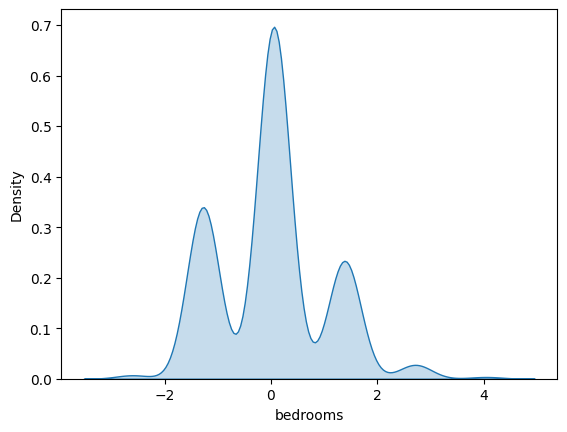

In [253]:
sns.kdeplot(x_train_scaled_df['bedrooms'], fill=True)

<Axes: xlabel='bedrooms'>

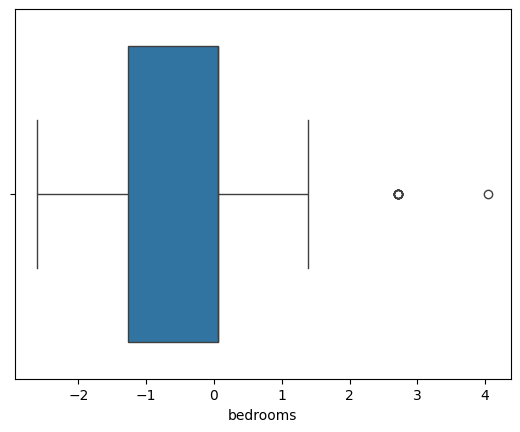

In [252]:
sns.boxplot(x_train_scaled_df['bedrooms'], orient='h')

<Axes: xlabel='bedrooms'>

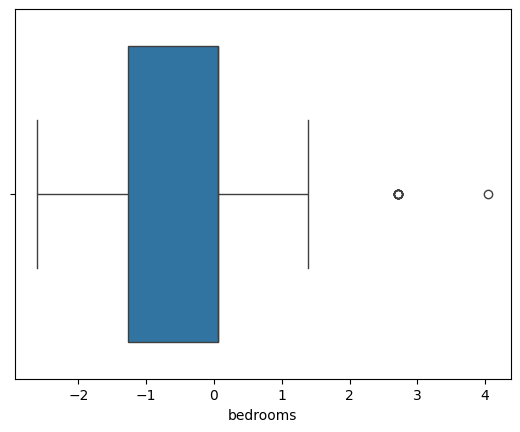

In [254]:
sns.boxplot(x_train_scaled_df['bedrooms'], orient='h')

## More easy and simple way to do the same (Using ColumnTransformer)

In [299]:
num_cols = x_train.drop(columns=x_train_cat_cols).columns.to_list()
num_cols

['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

In [300]:
cat_cols = x_train[x_train_cat_cols].columns.to_list()
cat_cols

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

In [303]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

In [304]:
x_train_processed = preprocessor.fit_transform(x_train)

In [314]:
x_train_processed

array([[ 0.93430081,  0.0558608 , -0.55323817, ...,  1.        ,
         0.        ,  1.        ],
       [-0.71024648, -1.27432452, -0.55323817, ...,  0.        ,
         1.        ,  0.        ],
       [-0.39016681, -1.27432452, -0.55323817, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.2889922 ,  0.0558608 ,  1.55459927, ...,  0.        ,
         0.        ,  0.        ],
       [-0.50053911, -1.27432452, -0.55323817, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.17089239,  0.0558608 ,  1.55459927, ...,  0.        ,
         1.        ,  0.        ]])

In [316]:
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out().tolist()
encoded_cat_cols

['mainroad_yes',
 'guestroom_yes',
 'basement_yes',
 'hotwaterheating_yes',
 'airconditioning_yes',
 'prefarea_yes',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

In [320]:
all_new_columns = num_cols + encoded_cat_cols
all_new_columns

['area',
 'bedrooms',
 'bathrooms',
 'stories',
 'parking',
 'mainroad_yes',
 'guestroom_yes',
 'basement_yes',
 'hotwaterheating_yes',
 'airconditioning_yes',
 'prefarea_yes',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

In [321]:
pd.DataFrame(
    x_train_processed,
    index=x_train.index,
    columns=all_new_columns
)

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
126,0.934301,0.055861,-0.553238,-0.907660,1.591603,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
363,-0.710246,-1.274325,-0.553238,-0.907660,-0.800511,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
370,-0.390167,-1.274325,-0.553238,-0.907660,1.591603,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
31,0.860719,0.055861,-0.553238,2.573733,1.591603,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
113,2.065617,0.055861,-0.553238,-0.907660,1.591603,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.400835,1.386046,1.554599,2.573733,-0.800511,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
106,0.147898,1.386046,1.554599,-0.907660,-0.800511,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
270,-0.288992,0.055861,1.554599,1.413269,0.395546,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
435,-0.500539,-1.274325,-0.553238,-0.907660,-0.800511,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [326]:
x_test_processed = preprocessor.transform(x_test)
x_test_processed

array([[ 0.35484623,  1.38604612,  1.55459927, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.63077698,  0.0558608 ,  1.55459927, ...,  1.        ,
         0.        ,  0.        ],
       [-0.50053911, -1.27432452, -0.55323817, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.33038181,  1.38604612,  3.66243672, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.78048845,  0.0558608 , -0.55323817, ...,  0.        ,
         1.        ,  0.        ],
       [-0.6798941 ,  0.0558608 ,  1.55459927, ...,  0.        ,
         1.        ,  0.        ]])

In [328]:
x_test_processed_df = pd.DataFrame(
    x_test_processed,
    index=x_test.index,
    columns=all_new_columns
)
x_test_processed_df

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,0.354846,1.386046,1.554599,0.252805,0.395546,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
77,0.630777,0.055861,1.554599,1.413269,-0.800511,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
360,-0.500539,-1.274325,-0.553238,-0.907660,-0.800511,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
90,-0.059050,0.055861,-0.553238,0.252805,-0.800511,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
493,-0.537330,0.055861,-0.553238,-0.907660,-0.800511,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,-0.702888,4.046417,-0.553238,0.252805,0.395546,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
425,-0.893740,-1.274325,-0.553238,-0.907660,1.591603,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
195,-0.330382,1.386046,3.662437,0.252805,1.591603,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
452,1.780488,0.055861,-0.553238,0.252805,1.591603,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
